# Within-County DiD: ZIP-Level Business Activity

**Motivation**: County-level SCM showed excellent pre-treatment fit but a non-significant permutation
p-value (p = 0.471–0.625), because Comal County's post-flood trajectory is not unusual among
fast-growing TX counties. This notebook builds a **within-county difference-in-differences** at the
ZIP code level, exploiting geographic variation in flood damage within Comal County and adjacent areas.

**Treatment assignment**: NFIP flood insurance claims from Oct–Nov 1998 show 75% of Comal County's
$22.5M in payouts concentrated in ZIP 78130 (New Braunfels downtown). This enables a clean
treated/control split.

**Data**: Census ZIP Code Business Patterns (ZBP), 1994–2020. Annual establishment counts,
employment, and payroll at 5-digit ZIP level.

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from src.utils.file_io import load_parquet
from src.process.deflator import load_deflator

pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 120)

## 1. NFIP Damage Crosswalk

Build treatment intensity from NFIP claims data for the Oct–Nov 1998 Guadalupe River flood.

In [2]:
# Load NFIP claims for 1998
nfip = load_parquet('../data/raw/fema_nfip/nfip_tx_1998.parquet')
nfip['dateOfLoss'] = pd.to_datetime(nfip['dateOfLoss'], errors='coerce')

# Filter to Comal County (48091), Oct–Nov 1998
flood = nfip[
    (nfip['countyCode'] == '48091') &
    (nfip['dateOfLoss'] >= '1998-10-01') &
    (nfip['dateOfLoss'] <= '1998-11-30')
].copy()

for col in ['amountPaidOnBuildingClaim', 'amountPaidOnContentsClaim',
            'amountPaidOnIncreasedCostOfComplianceClaim']:
    flood[col] = pd.to_numeric(flood[col], errors='coerce').fillna(0)

flood['total_paid'] = (
    flood['amountPaidOnBuildingClaim'] +
    flood['amountPaidOnContentsClaim'] +
    flood['amountPaidOnIncreasedCostOfComplianceClaim']
)

damage_by_zip = flood.groupby('reportedZipCode').agg(
    nfip_claims=('id', 'count'),
    nfip_total_paid=('total_paid', 'sum'),
    nfip_building_paid=('amountPaidOnBuildingClaim', 'sum'),
).reset_index().rename(columns={'reportedZipCode': 'zip'})

# Treatment assignment
damage_by_zip['treated'] = (damage_by_zip['nfip_total_paid'] > 500_000).astype(int)
damage_by_zip['intensity'] = np.log1p(damage_by_zip['nfip_total_paid'])

print('=== NFIP Damage by Comal County ZIP (Oct–Nov 1998) ===')
damage_by_zip['paid_fmt'] = damage_by_zip['nfip_total_paid'].apply(lambda x: f'${x:,.0f}')
print(damage_by_zip[['zip', 'nfip_claims', 'paid_fmt', 'treated']].to_string(index=False))
print(f"\nTotal: ${damage_by_zip['nfip_total_paid'].sum():,.0f} across {damage_by_zip['nfip_claims'].sum()} claims")

=== NFIP Damage by Comal County ZIP (Oct–Nov 1998) ===
  zip  nfip_claims    paid_fmt  treated
78070            1      $7,065        0
78130          173 $17,027,459        1
78131           10  $1,022,178        1
78132           45  $2,572,673        1
78133           10    $127,157        0
78163           31  $1,682,562        1
78266            8    $106,881        0

Total: $22,545,975 across 278 claims


## 2. Load & Prepare ZBP Data

In [3]:
# Load ZBP and CPI deflator
zbp = load_parquet('../data/raw/census_zbp/zbp_tx_zips.parquet')
cpi = load_deflator()
cpi_map = dict(zip(cpi['year'].astype(int), cpi['deflator'].astype(float)))

# Comal County ZIPs
comal_zips = ['78130', '78131', '78132', '78133', '78163', '78266', '78070']

# Adjacent county control ZIPs (non-flooded)
# Kendall County: Boerne (78006), Comfort (78013), Fair Oaks Ranch (78015)
# Hays County: Buda (78610), Dripping Springs (78620), Kyle (78640)
# Excluding: San Marcos (78666, $2M flood damage), Wimberley (78676, $1.5M)
# Excluding: all Guadalupe County (Seguin 78155 had $41M in 1998 flood damage)
adjacent_control_zips = ['78006', '78013', '78015', '78610', '78620', '78640']

all_zips = comal_zips + adjacent_control_zips
panel = zbp[zbp['zip'].isin(all_zips)].copy()

# Convert columns to numeric
for col in ['year', 'estab', 'emp', 'payann']:
    panel[col] = pd.to_numeric(panel[col], errors='coerce')
panel['year'] = panel['year'].astype(int)

# Deflate payroll to 2020 dollars (ZBP payann is in $1,000s)
panel['payann_nominal_k'] = panel['payann']  # in $1,000s
panel['deflator'] = panel['year'].map(cpi_map)
panel['payann_real'] = panel['payann_nominal_k'] * 1000 * panel['deflator']  # convert to $ then deflate

print(f'Panel shape: {panel.shape}')
print(f'ZIPs: {sorted(panel["zip"].unique())}')
print(f'Years: {panel["year"].min()}–{panel["year"].max()}')

Panel shape: (351, 8)
ZIPs: ['78006', '78013', '78015', '78070', '78130', '78131', '78132', '78133', '78163', '78266', '78610', '78620', '78640']
Years: 1994–2020


## 3. Merge Treatment Assignment

In [4]:
# Merge NFIP damage for Comal ZIPs
panel = panel.merge(damage_by_zip[['zip', 'treated', 'intensity', 'nfip_total_paid', 'nfip_claims']],
                    on='zip', how='left')

# Adjacent county ZIPs are controls (no Comal 1998 flood damage)
panel['treated'] = panel['treated'].fillna(0).astype(int)
panel['intensity'] = panel['intensity'].fillna(0)
panel['nfip_total_paid'] = panel['nfip_total_paid'].fillna(0)
panel['nfip_claims'] = panel['nfip_claims'].fillna(0).astype(int)

# Post-treatment indicator
panel['post'] = (panel['year'] >= 1999).astype(int)

# Log outcomes (adding 1 for zeros in emp)
panel['ln_estab'] = np.log(panel['estab'].clip(lower=1))
panel['ln_emp'] = np.log(panel['emp'].clip(lower=1))
panel['ln_payann_real'] = np.log(panel['payann_real'].clip(lower=1))

# County indicator for Comal vs adjacent
panel['comal'] = panel['zip'].isin(comal_zips).astype(int)

# Label for plotting
zip_labels = {
    '78130': 'NB Downtown', '78131': 'NB', '78132': 'NB Outskirts',
    '78133': 'Canyon Lake', '78163': 'Bulverde', '78266': 'Garden Ridge',
    '78070': 'Spring Branch',
    '78006': 'Boerne', '78013': 'Comfort', '78015': 'Fair Oaks Ranch',
    '78610': 'Buda', '78620': 'Dripping Springs', '78640': 'Kyle',
}
panel['zip_label'] = panel['zip'].map(zip_labels)

print('\n=== Treatment Assignment ===')
summary = panel.drop_duplicates('zip')[['zip', 'zip_label', 'comal', 'treated', 'nfip_claims', 'nfip_total_paid']].sort_values('nfip_total_paid', ascending=False)
summary['paid_fmt'] = summary['nfip_total_paid'].apply(lambda x: f'${x:,.0f}' if x > 0 else '$0')
print(summary[['zip', 'zip_label', 'comal', 'treated', 'nfip_claims', 'paid_fmt']].to_string(index=False))


=== Treatment Assignment ===
  zip        zip_label  comal  treated  nfip_claims    paid_fmt
78130      NB Downtown      1        1          173 $17,027,459
78132     NB Outskirts      1        1           45  $2,572,673
78163         Bulverde      1        1           31  $1,682,562
78131               NB      1        1           10  $1,022,178
78133      Canyon Lake      1        0           10    $127,157
78266     Garden Ridge      1        0            8    $106,881
78070    Spring Branch      1        0            1      $7,065
78006           Boerne      0        0            0          $0
78013          Comfort      0        0            0          $0
78015  Fair Oaks Ranch      0        0            0          $0
78610             Buda      0        0            0          $0
78620 Dripping Springs      0        0            0          $0
78640             Kyle      0        0            0          $0


## 4. Pre-Treatment Trends (Visual Parallel Trends Check)

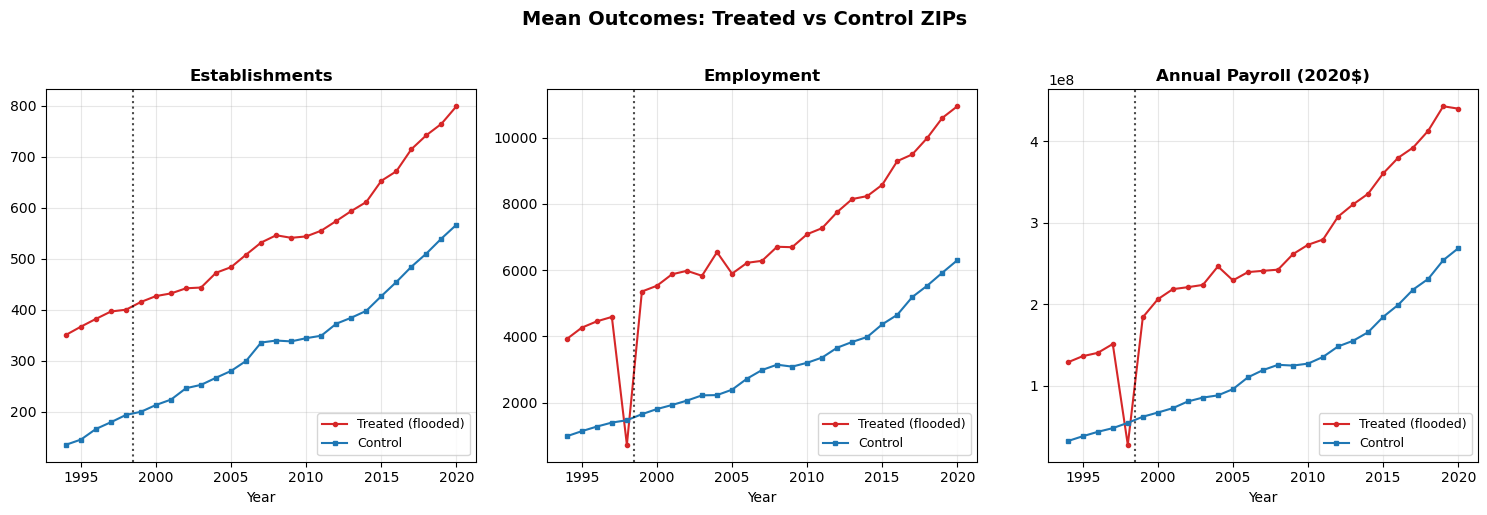

Saved: data/results/figures/did_raw_trends.png


In [5]:
# Aggregate treated vs control
grouped = panel.groupby(['year', 'treated']).agg(
    estab=('estab', 'mean'),
    emp=('emp', 'mean'),
    payann_real=('payann_real', 'mean'),
).reset_index()

treated = grouped[grouped['treated'] == 1]
control = grouped[grouped['treated'] == 0]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, var, title, fmt in zip(
    axes,
    ['estab', 'emp', 'payann_real'],
    ['Establishments', 'Employment', 'Annual Payroll (2020$)'],
    ['{x:,.0f}', '{x:,.0f}', '${x:,.0f}']
):
    ax.plot(treated['year'], treated[var], 'o-', color='#d62728', label='Treated (flooded)', markersize=3)
    ax.plot(control['year'], control[var], 's-', color='#1f77b4', label='Control', markersize=3)
    ax.axvline(1998.5, color='black', linestyle=':', alpha=0.7)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Year')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

fig.suptitle('Mean Outcomes: Treated vs Control ZIPs', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../data/results/figures/did_raw_trends.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: data/results/figures/did_raw_trends.png')

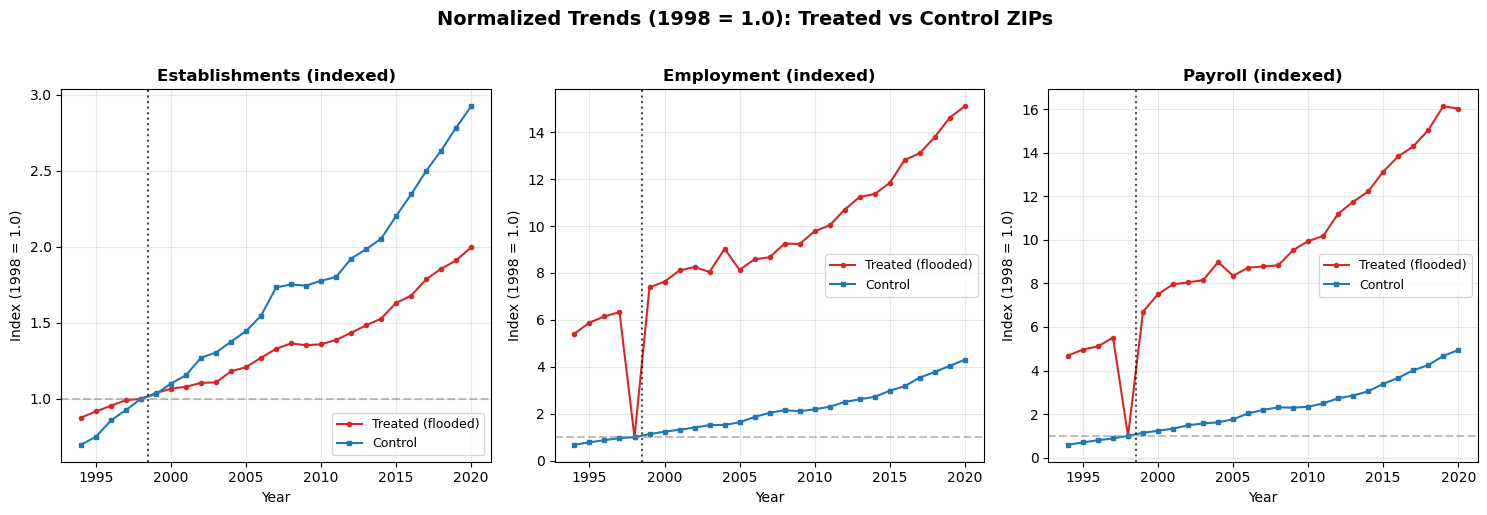

Saved: data/results/figures/did_indexed_trends.png


In [6]:
# Normalized trends (index = 1 in 1998) for better parallel trends visualization
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, var, title in zip(
    axes,
    ['estab', 'emp', 'payann_real'],
    ['Establishments (indexed)', 'Employment (indexed)', 'Payroll (indexed)'],
):
    for grp, color, label, marker in [
        (1, '#d62728', 'Treated (flooded)', 'o'),
        (0, '#1f77b4', 'Control', 's'),
    ]:
        g = grouped[grouped['treated'] == grp]
        base = g.loc[g['year'] == 1998, var].values
        if len(base) > 0 and base[0] > 0:
            ax.plot(g['year'], g[var] / base[0], f'{marker}-', color=color, label=label, markersize=3)
    ax.axvline(1998.5, color='black', linestyle=':', alpha=0.7)
    ax.axhline(1.0, color='gray', linestyle='--', alpha=0.5)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Year')
    ax.set_ylabel('Index (1998 = 1.0)')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

fig.suptitle('Normalized Trends (1998 = 1.0): Treated vs Control ZIPs', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../data/results/figures/did_indexed_trends.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: data/results/figures/did_indexed_trends.png')

## 5. Individual ZIP Trends

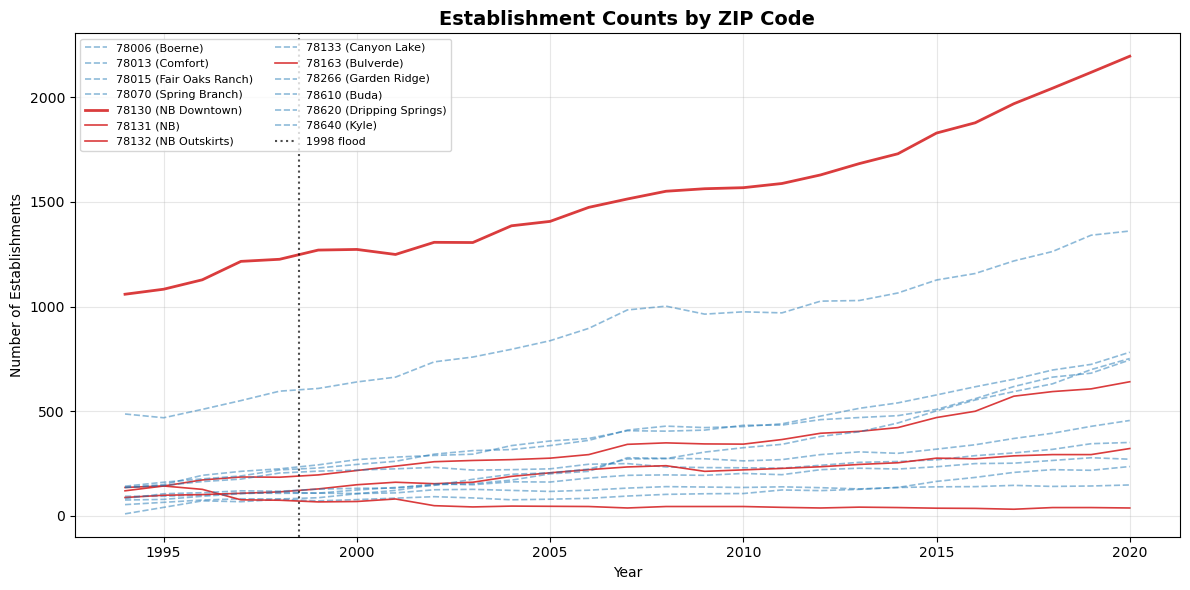

Saved: data/results/figures/did_zip_trends.png


In [7]:
# Plot individual ZIP trends for establishments
fig, ax = plt.subplots(figsize=(12, 6))

for z in sorted(panel['zip'].unique()):
    zdata = panel[panel['zip'] == z]
    is_treated = zdata['treated'].iloc[0] == 1
    label = f"{z} ({zip_labels.get(z, '')})"
    color = '#d62728' if is_treated else '#1f77b4'
    ls = '-' if is_treated else '--'
    alpha = 0.9 if is_treated else 0.5
    lw = 2 if z == '78130' else 1.2
    ax.plot(zdata['year'], zdata['estab'], ls, color=color, alpha=alpha, linewidth=lw, label=label)

ax.axvline(1998.5, color='black', linestyle=':', alpha=0.7, label='1998 flood')
ax.set_title('Establishment Counts by ZIP Code', fontsize=14, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Number of Establishments')
ax.legend(fontsize=8, ncol=2, loc='upper left')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../data/results/figures/did_zip_trends.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: data/results/figures/did_zip_trends.png')

## 6. Save DiD Panel for R Estimation

In [8]:
# Select columns for R
out_cols = [
    'zip', 'year', 'zip_label', 'comal',
    'estab', 'emp', 'payann_real',
    'ln_estab', 'ln_emp', 'ln_payann_real',
    'treated', 'intensity', 'post',
    'nfip_total_paid', 'nfip_claims'
]
did_panel = panel[out_cols].sort_values(['zip', 'year']).reset_index(drop=True)

# Save CSV for R
did_panel.to_csv('../data/processed/panels/did_zbp_panel.csv', index=False)
print(f'Saved DiD panel: {did_panel.shape[0]} rows, {did_panel.shape[1]} cols')
print(f'ZIPs: {did_panel["zip"].nunique()} ({did_panel["treated"].sum() // did_panel["year"].nunique()} treated, '
      f'{(1 - did_panel["treated"]).sum() // did_panel["year"].nunique()} control)')
print(f'Years: {did_panel["year"].min()}–{did_panel["year"].max()}')
print(f'\nSample:')
print(did_panel.head(10).to_string(index=False))

Saved DiD panel: 351 rows, 15 cols
ZIPs: 13 (4 treated, 9 control)
Years: 1994–2020

Sample:
  zip  year zip_label  comal  estab  emp       payann_real  ln_estab    ln_emp  ln_payann_real  treated  intensity  post  nfip_total_paid  nfip_claims
78006  1994    Boerne      0    487 3559  101248888.981107  6.188264  8.177235       18.433092        0        0.0     0              0.0            0
78006  1995    Boerne      0    469 4038  113890425.879265  6.150603  8.303505       18.550747        0        0.0     0              0.0            0
78006  1996    Boerne      0    509 4456  149302111.102613  6.232448  8.402007       18.821482        0        0.0     0              0.0            0
78006  1997    Boerne      0    551 5016  154252968.529595  6.311735  8.520388       18.854104        0        0.0     0              0.0            0
78006  1998    Boerne      0    596 4875  168162050.300613  6.390241  8.491875       18.940439        0        0.0     0              0.0            0
7

In [9]:
# Summary statistics
print('=== Pre-Treatment Summary (1994–1998) ===')
pre = did_panel[did_panel['year'] <= 1998]
for grp, label in [(1, 'Treated'), (0, 'Control')]:
    g = pre[pre['treated'] == grp]
    print(f'\n{label} ZIPs ({g["zip"].nunique()}):')
    print(g[['estab', 'emp', 'payann_real']].describe().round(1).to_string())

print('\n=== Post-Treatment Summary (1999–2020) ===')
post = did_panel[did_panel['year'] >= 1999]
for grp, label in [(1, 'Treated'), (0, 'Control')]:
    g = post[post['treated'] == grp]
    print(f'\n{label} ZIPs ({g["zip"].nunique()}):')
    print(g[['estab', 'emp', 'payann_real']].describe().round(1).to_string())

=== Pre-Treatment Summary (1994–1998) ===

Treated ZIPs (4):
        estab      emp  payann_real
count    20.0     20.0         20.0
mean    379.4   3590.6  116797322.1
std     454.4   5710.1  179089011.7
min      75.0      0.0          0.0
25%     106.5    507.5   13459992.3
50%     139.5   1027.0   33817661.2
75%     404.2   1410.2   61613994.1
max    1226.0  15646.0  503236623.5

Control ZIPs (9):
       estab     emp  payann_real
count   45.0    45.0         45.0
mean   164.2  1251.9   43131692.8
std    138.0  1237.6   42240828.9
min     10.0    37.0    1503618.6
25%     82.0   664.0   16368660.6
50%    113.0   767.0   22700306.0
75%    177.0  1374.0   58159104.9
max    596.0  5016.0  168162050.3

=== Post-Treatment Summary (1999–2020) ===

Treated ZIPs (4):
        estab      emp   payann_real
count    88.0     88.0          88.0
mean    566.8   7470.5   293742400.2
std     639.9   9458.0   353367114.3
min      32.0      0.0     7744376.8
25%     117.0    869.0    32273892.5
50%  

## 7. Employment Data Quality Check

ZBP suppresses employment for small ZIPs (showing 0 instead of actual). Check which ZIPs are affected.

In [10]:
# Check for zero employment (suppression indicator)
emp_check = did_panel.pivot_table(index='zip', columns='year', values='emp', aggfunc='first')
zero_pct = (emp_check == 0).mean(axis=1)

print('=== Employment Suppression Check ===')
print('Fraction of years with emp=0 by ZIP:')
for z in sorted(did_panel['zip'].unique()):
    pct = zero_pct.get(z, 0)
    label = zip_labels.get(z, '')
    flag = ' *** SUPPRESSED' if pct > 0.1 else ''
    print(f'  {z} ({label:20s}): {pct:.0%}{flag}')

print('\nNote: ZBP suppresses employment when disclosure rules apply.')
print('Establishments and payroll are NOT suppressed — use these as primary outcomes.')

=== Employment Suppression Check ===
Fraction of years with emp=0 by ZIP:
  78006 (Boerne              ): 0%
  78013 (Comfort             ): 0%
  78015 (Fair Oaks Ranch     ): 0%
  78070 (Spring Branch       ): 0%
  78130 (NB Downtown         ): 4%
  78131 (NB                  ): 4%
  78132 (NB Outskirts        ): 0%
  78133 (Canyon Lake         ): 0%
  78163 (Bulverde            ): 0%
  78266 (Garden Ridge        ): 0%
  78610 (Buda                ): 0%
  78620 (Dripping Springs    ): 0%
  78640 (Kyle                ): 0%

Note: ZBP suppresses employment when disclosure rules apply.
Establishments and payroll are NOT suppressed — use these as primary outcomes.


## Next Steps

The DiD panel is saved to `data/processed/panels/did_zbp_panel.csv`. 
Run `R/03_did_zbp.R` for:

1. **Binary DiD**: `feols(ln_estab ~ treated:post | zip + year)` — average treatment effect
2. **Event study**: `feols(ln_estab ~ i(year, treated, ref=1998) | zip + year)` — dynamic effects
3. **Continuous intensity**: `feols(ln_estab ~ intensity:post | zip + year)` — dose-response
4. **Robustness**: Comal-only panel (7 ZIPs) vs expanded (13 ZIPs)